In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# K-means vs Hierachical clustering methods on Normal vs Gamma distributions


## 1. Load and Prepare Data

Load the simulation results and verify the data structure.

In [2]:
# Load results
df = pd.read_csv("../02_clustering/clustering_results_final.csv")

print(f"📊 Dataset Shape: {df.shape}")
print(f"📁 Columns: {list(df.columns)}")
print(f"\n🔍 First few rows:")
df.head()

📊 Dataset Shape: (7200, 18)
📁 Columns: ['N', 'p', 'k', 'rho', 'sep', 'rep', 'syn_idx', 'distribution', 'success_kmeans', 'success_hc', 'diff_sil_km', 'diff_sil_hc', 'diff_dist_km', 'diff_dist_hc', 'sil_real_km', 'sil_syn_km', 'dist_real_km', 'dist_syn_km']

🔍 First few rows:


,N,p,k,rho,sep,rep,syn_idx,distribution,success_kmeans,success_hc,diff_sil_km,diff_sil_hc,diff_dist_km,diff_dist_hc,sil_real_km,sil_syn_km,dist_real_km,dist_syn_km
0,1000,10,2,0.4,0.1,1,10,gamma,1,1,0.008837,0.084610,0.024327,0.554743,0.276499,0.285336,3.550478,3.574805
1,1000,10,2,0.4,0.1,1,10,normal,1,1,-0.002692,-0.004336,-0.042789,-0.111338,0.244282,0.241589,3.502689,3.459901
2,1000,10,2,0.4,0.1,1,1,gamma,1,1,-0.026160,0.004282,-0.237476,-0.001937,0.276499,0.250339,3.550478,3.313001
3,1000,10,2,0.4,0.1,1,1,normal,1,1,0.023875,0.025084,0.146598,0.187302,0.244282,0.268157,3.502689,3.649287
4,1000,10,2,0.4,0.1,1,2,gamma,1,1,-0.003245,-0.010597,-0.070826,-0.037634,0.276499,0.273254,3.550478,3.479652


In [3]:
print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(f"\n✓ Total synthetic datasets processed: {len(df)}")

# --- Helper to convert numpy/pandas scalars to native Python types for nice printing ---
def _to_py_list(arr, sort=True):
    vals = np.asarray(arr)
    py = [v.item() if hasattr(v, "item") else v for v in vals]
    return sorted(py) if sort else py

N_vals = _to_py_list(df["N"].unique())
p_vals = _to_py_list(df["p"].unique())
k_vals = _to_py_list(df["k"].unique())
sep_vals = _to_py_list(df["sep"].unique())
rho_vals = _to_py_list(df["rho"].unique())
rep_vals = _to_py_list(df["rep"].unique())

num_real = len(N_vals) * len(p_vals) * len(k_vals) * len(sep_vals) * len(rho_vals)
num_rep = len(rep_vals)

# determine how many dataframe rows correspond to one (N,p,k,sep,rho,rep) entry
per_rep_counts = df.groupby(["N", "p", "k", "sep", "rho", "rep"]).size()
unique_per_rep = np.unique(per_rep_counts.values)
if unique_per_rep.size == 1:
    rows_per_rep = int(unique_per_rep[0])
    rows_info = f"{rows_per_rep} rows per (N,p,k,sep,rho,rep)"
else:
    rows_per_rep = None
    rows_info = f"varying rows per (N,p,k,sep,rho,rep): {unique_per_rep.tolist()}"

expected = num_real * num_rep * (rows_per_rep if rows_per_rep is not None else 1)

print(f"✓ Expected ({num_real} real × {num_rep} rep × {rows_info}): {expected}")
print(f"✓ Match: {'YES ✅' if len(df) == expected else 'NO ❌'}")

print("\n✓ Unique parameter combinations:")
print(f"  - N values: {N_vals}")
print(f"  - p values: {p_vals}")
print(f"  - k values: {k_vals}")
print(f"  - separation values: {sep_vals}")
print(f"  - rho values: {rho_vals}")

print(f"\n✓ Synthetic replications per real dataset (by rep value):")
print(f"  - Min rows per rep: {per_rep_counts.min()}")
print(f"  - Max rows per rep: {per_rep_counts.max()}")
print(f"  - Unique rep values: {num_rep}")

print("\n✅ Data validation complete")

DATA VALIDATION

✓ Total synthetic datasets processed: 7200
✓ Expected (72 real × 5 rep × 20 rows per (N,p,k,sep,rho,rep)): 7200
✓ Match: YES ✅

✓ Unique parameter combinations:
  - N values: [1000]
  - p values: [2, 5, 10]
  - k values: [2, 3, 4]
  - separation values: [0.1, 2.0, 6.0, 10.0]
  - rho values: [0.0, 0.4]

✓ Synthetic replications per real dataset (by rep value):
  - Min rows per rep: 20
  - Max rows per rep: 20
  - Unique rep values: 5

✅ Data validation complete


## 2. Data visualization and dimensionality reduction

Load the simulation results and verify the data structure.

ALGORITHM COMPARISON: REAL vs SYNTHETIC DATA

NORMAL DISTRIBUTION

Loading Normal distribution data...
  Real: (1000, 10), Synthetic: (1000, 10)

Applying PCA to Normal data...
  Variance explained: 28.5% (PC1: 17.6%, PC2: 10.9%)

Creating NORMAL Distribution Grid
  Running K-Means on Real data...
  Running Hierarchical on Real data...
  Running K-Means on Synthetic data...
  Running Hierarchical on Synthetic data...
  Saving figure to: /mnt/c/Users/sterr/Desktop/ML_SyntheticDataResearch/ofarres/03_analysis/normal_analysis_grid.png
  ✓ Figure saved successfully (DPI=300)

GAMMA DISTRIBUTION

Loading Gamma distribution data...
  Real: (1000, 10), Synthetic: (1000, 10)

Applying PCA to Gamma data...
  Variance explained: 28.6% (PC1: 17.2%, PC2: 11.4%)

Creating GAMMA Distribution Grid
  Running K-Means on Real data...
  Running Hierarchical on Real data...
  Running K-Means on Synthetic data...
  Running Hierarchical on Synthetic data...
  Saving figure to: /mnt/c/Users/sterr/Desktop/ML_

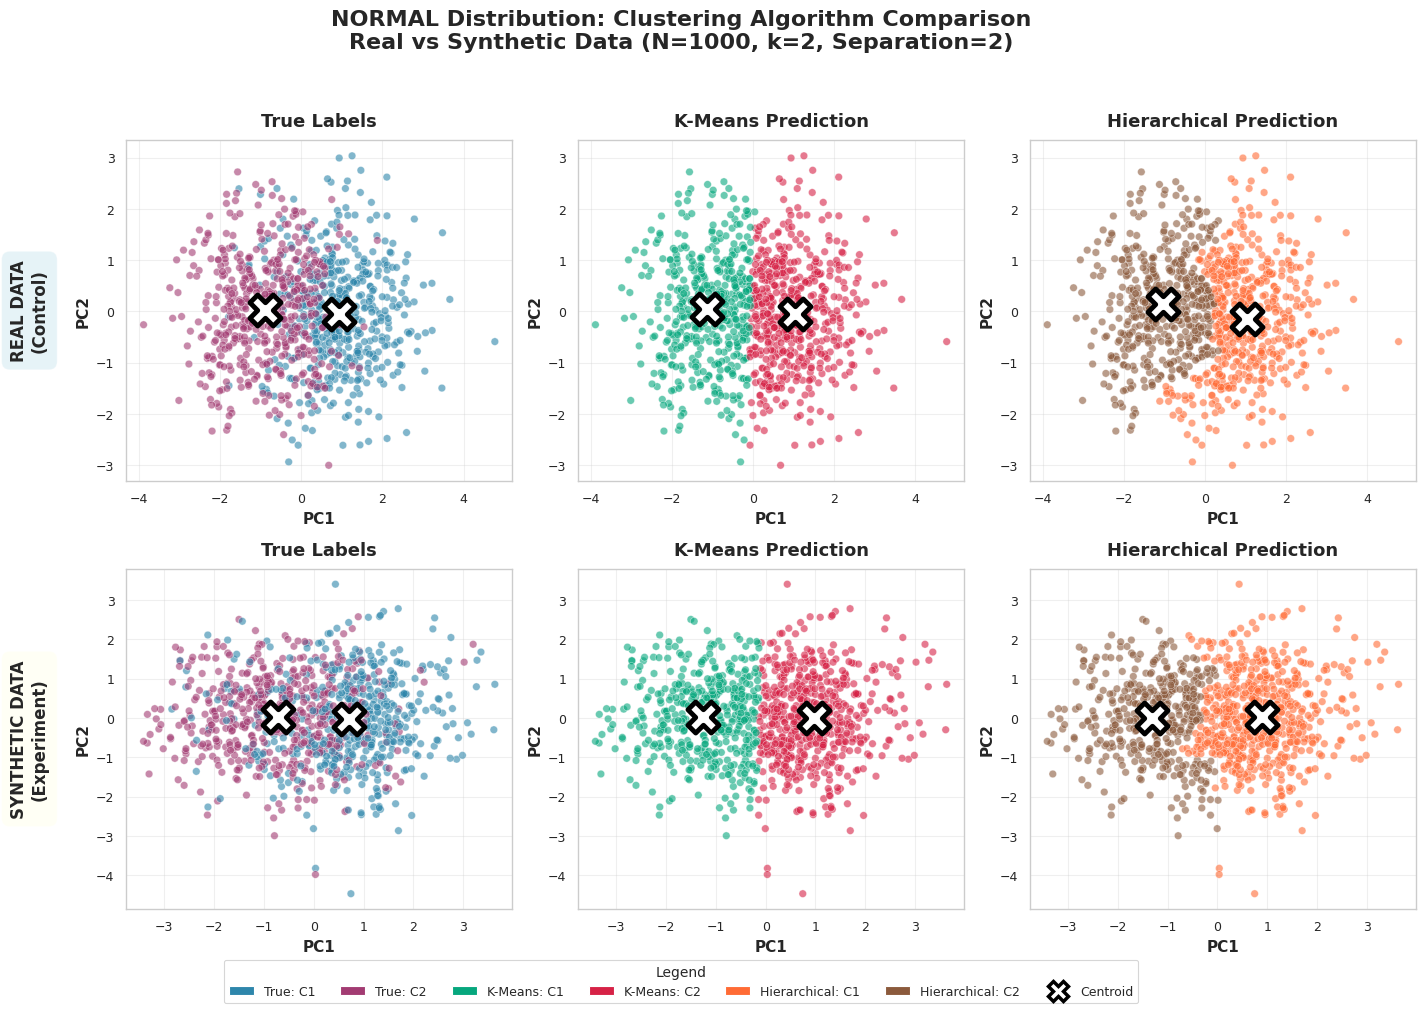

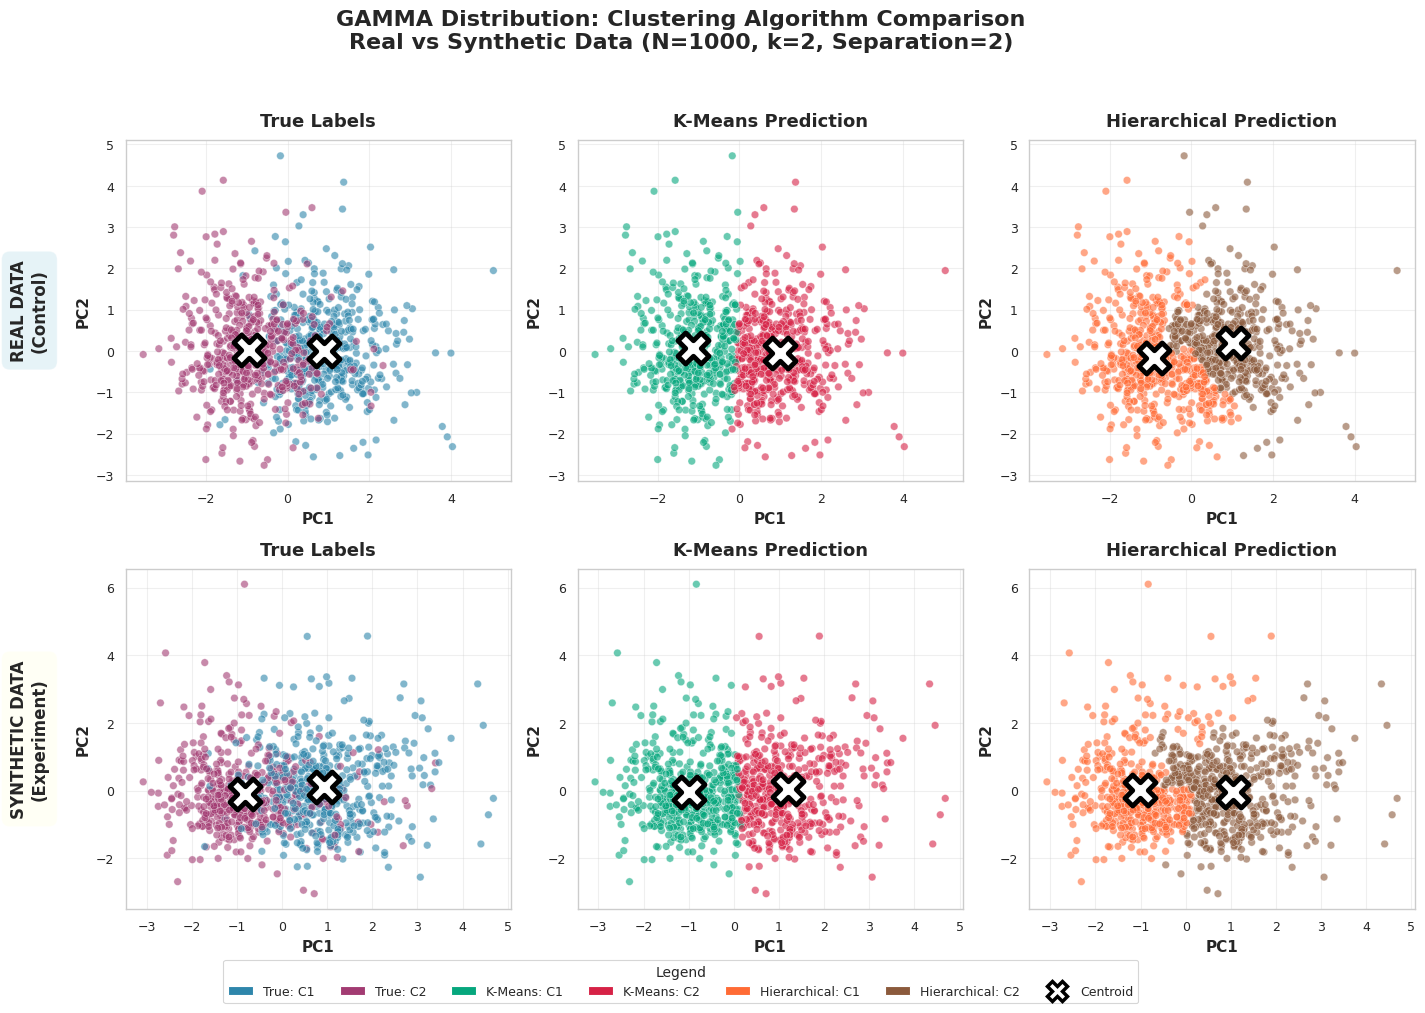

In [4]:
"""
Publication-Quality Visualization: Algorithm Comparison on Real vs Synthetic Data
=================================================================================

Generate two separate 2×3 grid visualizations:
- normal_analysis_grid.png: Normal distribution analysis
- gamma_analysis_grid.png: Gamma distribution analysis

Layout for each grid:
- Row 1: Real Data (Control)
- Row 2: Synthetic Data (Experiment)
- Column 1: True Labels (Ground Truth)
- Column 2: K-Means Predictions
- Column 3: Hierarchical Predictions
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

# Data parameters
N = 1000
K = 2
SEPARATION = 2
REP = 1
SYN_ID = 1

# File paths
BASE_PATH = '/mnt/c/Users/sterr/Desktop/ML_SyntheticDataResearch/ofarres'
DATA_PATH_REAL = f'{BASE_PATH}/data/real'
DATA_PATH_SYN = f'{BASE_PATH}/data/synthetic'

# Output configuration
OUTPUT_NORMAL = f'{BASE_PATH}/03_analysis/normal_analysis_grid.png'
OUTPUT_GAMMA = f'{BASE_PATH}/03_analysis/gamma_analysis_grid.png'
DPI = 300
FIGSIZE = (15, 10)

# Styling
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10

# Distinct color schemes for different algorithms
colors_true = ['#2E86AB', '#A23B72']          # Blue/Purple for Ground Truth
colors_kmeans = ['#06A77D', '#D62246']        # Green/Red for K-Means
colors_hierarchical = ['#FF6B35', '#8B5A3C']  # Orange/Brown for Hierarchical
cmap_true = ListedColormap(colors_true)
cmap_kmeans = ListedColormap(colors_kmeans)
cmap_hierarchical = ListedColormap(colors_hierarchical)

print("="*70)
print("ALGORITHM COMPARISON: REAL vs SYNTHETIC DATA")
print("="*70)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_dataset(distribution):
    """Load real and synthetic data for a given distribution"""
    real_file = f'N{N}_p10_k{K}_rho0_sep{SEPARATION}_rep{REP}_{distribution}.csv'
    syn_file = f'N{N}_p10_k{K}_rho0_sep{SEPARATION}_rep{REP}_syn{SYN_ID}_{distribution}.csv'
    
    real_df = pd.read_csv(f'{DATA_PATH_REAL}/{real_file}')
    syn_df = pd.read_csv(f'{DATA_PATH_SYN}/{syn_file}')
    
    feature_cols = [col for col in real_df.columns if col.startswith('X')]
    
    X_real = real_df[feature_cols].values
    y_real = real_df['group'].values.astype(int)
    
    X_syn = syn_df[feature_cols].values
    y_syn = syn_df['group'].values.astype(int)
    
    return X_real, y_real, X_syn, y_syn

def reduce_to_2d(X_real, X_syn):
    """Apply PCA to combined data for shared coordinate system"""
    X_combined = np.vstack([X_real, X_syn])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_combined)
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    n_real = X_real.shape[0]
    return X_pca[:n_real], X_pca[n_real:], pca.explained_variance_ratio_

def apply_kmeans(X_pca, k=2):
    """Apply K-Means clustering"""
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    return kmeans.fit_predict(X_pca)

def apply_hierarchical(X_pca, k=2):
    """Apply Hierarchical (Agglomerative) clustering"""
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    return hierarchical.fit_predict(X_pca)

def plot_scatter(ax, X, labels, title, cmap, xlabel='PC1', ylabel='PC2', alpha=0.6):
    """Plot scatter with prominent centroids"""
    # Convert labels to 0-indexed if needed
    labels_indexed = labels - 1 if labels.min() == 1 else labels
    
    # Scatter plot
    scatter = ax.scatter(
        X[:, 0], X[:, 1],
        c=labels_indexed,
        cmap=cmap,
        alpha=alpha,
        s=30,
        edgecolors='white',
        linewidth=0.4
    )
    
    # Calculate and plot centroids
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        centroid = X[mask].mean(axis=0)
        # PROMINENT CENTROID: Large white X with thick black outline
        ax.scatter(centroid[0], centroid[1], 
                  marker='X', s=500, c='white',
                  edgecolors='black', linewidth=3.5, zorder=10)
    
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    
    return scatter

def create_analysis_grid(X_real_pca, y_real, X_syn_pca, y_syn, distribution_name, output_file):
    """Create 2×3 grid for a single distribution"""
    
    print(f"\n{'='*60}")
    print(f"Creating {distribution_name.upper()} Distribution Grid")
    print(f"{'='*60}")
    
    # Apply clustering algorithms to both datasets
    print(f"  Running K-Means on Real data...")
    labels_kmeans_real = apply_kmeans(X_real_pca, K)
    
    print(f"  Running Hierarchical on Real data...")
    labels_hierarchical_real = apply_hierarchical(X_real_pca, K)
    
    print(f"  Running K-Means on Synthetic data...")
    labels_kmeans_syn = apply_kmeans(X_syn_pca, K)
    
    print(f"  Running Hierarchical on Synthetic data...")
    labels_hierarchical_syn = apply_hierarchical(X_syn_pca, K)
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)
    
    # ========================================================================
    # ROW 1: REAL DATA (CONTROL)
    # ========================================================================
    
    # Column 1: True Labels
    plot_scatter(axes[0, 0], X_real_pca, y_real, 'True Labels', cmap_true)
    
    # Column 2: K-Means Predictions
    plot_scatter(axes[0, 1], X_real_pca, labels_kmeans_real + 1, 'K-Means Prediction', cmap_kmeans)
    
    # Column 3: Hierarchical Predictions
    plot_scatter(axes[0, 2], X_real_pca, labels_hierarchical_real + 1, 'Hierarchical Prediction', cmap_hierarchical)
    
    # Add row label
    axes[0, 0].annotate('REAL DATA\n(Control)', xy=(-0.25, 0.5), xycoords='axes fraction',
                        fontsize=12, fontweight='bold', rotation=90,
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))
    
    # ========================================================================
    # ROW 2: SYNTHETIC DATA (EXPERIMENT)
    # ========================================================================
    
    # Column 1: True Labels
    plot_scatter(axes[1, 0], X_syn_pca, y_syn, 'True Labels', cmap_true)
    
    # Column 2: K-Means Predictions
    plot_scatter(axes[1, 1], X_syn_pca, labels_kmeans_syn + 1, 'K-Means Prediction', cmap_kmeans)
    
    # Column 3: Hierarchical Predictions
    plot_scatter(axes[1, 2], X_syn_pca, labels_hierarchical_syn + 1, 'Hierarchical Prediction', cmap_hierarchical)
    
    # Add row label
    axes[1, 0].annotate('SYNTHETIC DATA\n(Experiment)', xy=(-0.25, 0.5), xycoords='axes fraction',
                        fontsize=12, fontweight='bold', rotation=90,
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.3))
    
    # ========================================================================
    # TITLE AND LEGEND
    # ========================================================================
    
    fig.suptitle(
        f'{distribution_name.upper()} Distribution: Clustering Algorithm Comparison\n'
        f'Real vs Synthetic Data (N={N}, k={K}, Separation={SEPARATION})',
        fontsize=16, fontweight='bold', y=0.98
    )
    
    # Create legend with three distinct colormaps
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Patch(facecolor=colors_true[0], edgecolor='white', label='True: C1'),
        Patch(facecolor=colors_true[1], edgecolor='white', label='True: C2'),
        Patch(facecolor=colors_kmeans[0], edgecolor='white', label='K-Means: C1'),
        Patch(facecolor=colors_kmeans[1], edgecolor='white', label='K-Means: C2'),
        Patch(facecolor=colors_hierarchical[0], edgecolor='white', label='Hierarchical: C1'),
        Patch(facecolor=colors_hierarchical[1], edgecolor='white', label='Hierarchical: C2'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=2.5, markersize=15, label='Centroid')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=7, 
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02),
               title='Legend', title_fontsize=10)
    
    plt.tight_layout(rect=[0.05, 0.02, 1, 0.95])
    
    # Save figure
    print(f"  Saving figure to: {output_file}")
    fig.savefig(output_file, dpi=DPI, bbox_inches='tight', facecolor='white')
    print(f"  ✓ Figure saved successfully (DPI={DPI})")
    
    return fig

# ============================================================================
# LOAD AND PROCESS NORMAL DISTRIBUTION
# ============================================================================

print("\n" + "="*70)
print("NORMAL DISTRIBUTION")
print("="*70)

print("\nLoading Normal distribution data...")
X_real_normal, y_real_normal, X_syn_normal, y_syn_normal = load_dataset('normal')
print(f"  Real: {X_real_normal.shape}, Synthetic: {X_syn_normal.shape}")

print("\nApplying PCA to Normal data...")
X_real_normal_pca, X_syn_normal_pca, var_normal = reduce_to_2d(X_real_normal, X_syn_normal)
print(f"  Variance explained: {var_normal.sum():.1%} (PC1: {var_normal[0]:.1%}, PC2: {var_normal[1]:.1%})")

fig_normal = create_analysis_grid(
    X_real_normal_pca, y_real_normal, 
    X_syn_normal_pca, y_syn_normal,
    'Normal', OUTPUT_NORMAL
)

# ============================================================================
# LOAD AND PROCESS GAMMA DISTRIBUTION
# ============================================================================

print("\n" + "="*70)
print("GAMMA DISTRIBUTION")
print("="*70)

print("\nLoading Gamma distribution data...")
X_real_gamma, y_real_gamma, X_syn_gamma, y_syn_gamma = load_dataset('gamma')
print(f"  Real: {X_real_gamma.shape}, Synthetic: {X_syn_gamma.shape}")

print("\nApplying PCA to Gamma data...")
X_real_gamma_pca, X_syn_gamma_pca, var_gamma = reduce_to_2d(X_real_gamma, X_syn_gamma)
print(f"  Variance explained: {var_gamma.sum():.1%} (PC1: {var_gamma[0]:.1%}, PC2: {var_gamma[1]:.1%})")

fig_gamma = create_analysis_grid(
    X_real_gamma_pca, y_real_gamma, 
    X_syn_gamma_pca, y_syn_gamma,
    'Gamma', OUTPUT_GAMMA
)

plt.show()


Processing NORMAL Distribution...
  Running t-SNE (this may take a moment)...


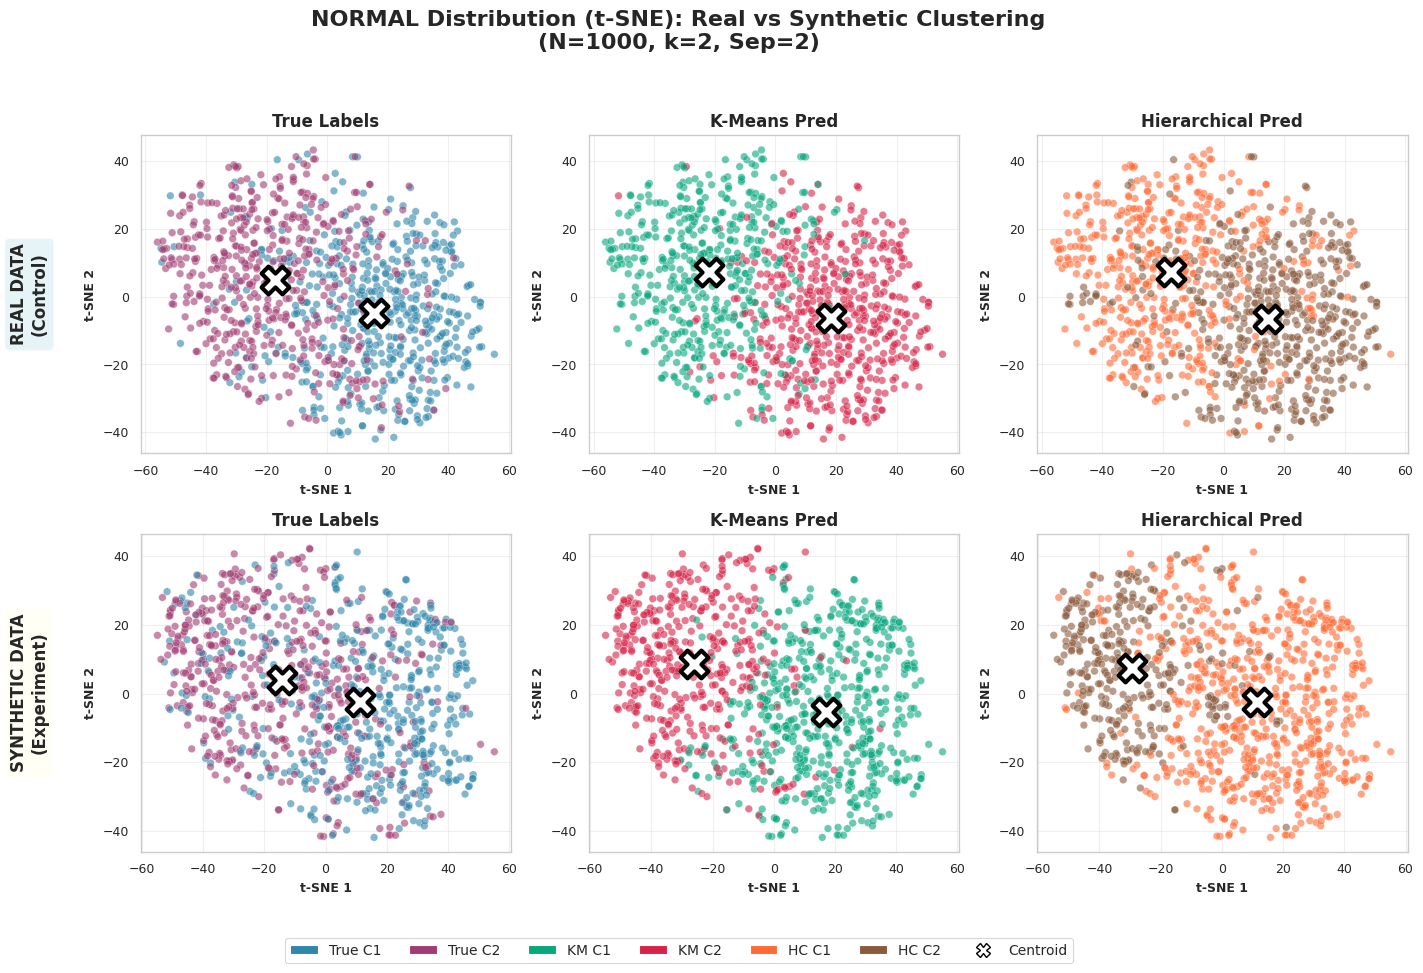


Processing GAMMA Distribution...
  Running t-SNE (this may take a moment)...


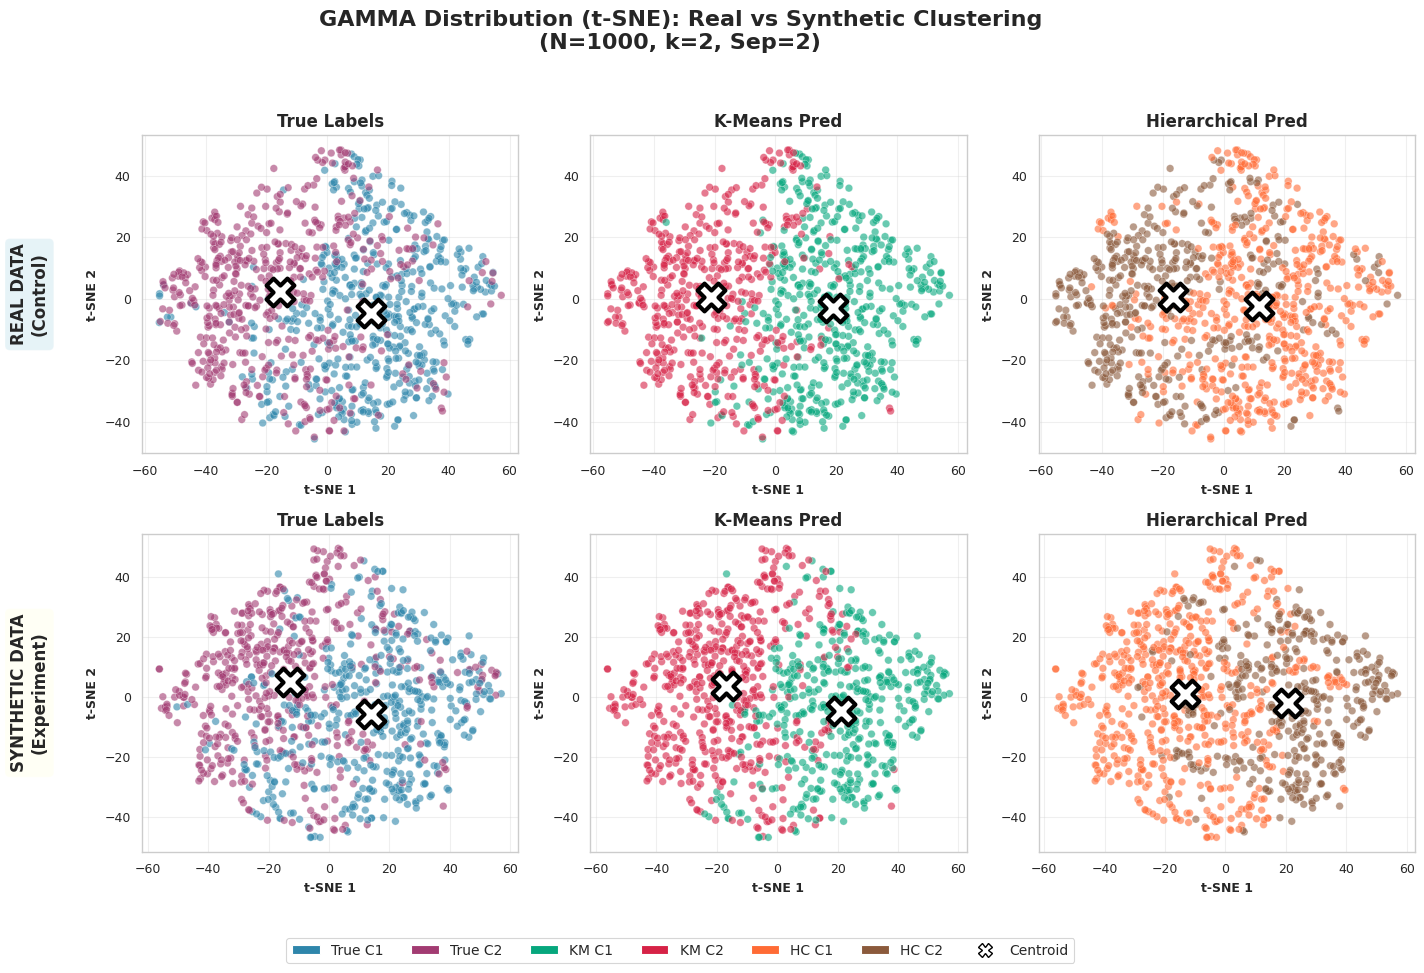

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

# Data parameters
N = 1000
K = 2
SEPARATION = 2
REP = 1
SYN_ID = 1

# File paths (Adjust as needed)
BASE_PATH = '/mnt/c/Users/sterr/Desktop/ML_SyntheticDataResearch/ofarres'
DATA_PATH_REAL = f'{BASE_PATH}/data/real'
DATA_PATH_SYN = f'{BASE_PATH}/data/synthetic'

# Styling
sns.set_style('whitegrid')
FIGSIZE = (15, 10)

# Colors
colors_true = ['#2E86AB', '#A23B72']          # Blue/Purple
colors_kmeans = ['#06A77D', '#D62246']        # Green/Red
colors_hierarchical = ['#FF6B35', '#8B5A3C']  # Orange/Brown
cmap_true = ListedColormap(colors_true)
cmap_kmeans = ListedColormap(colors_kmeans)
cmap_hierarchical = ListedColormap(colors_hierarchical)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_dataset(distribution):
    """Load real and synthetic data"""
    real_file = f'N{N}_p10_k{K}_rho0_sep{SEPARATION}_rep{REP}_{distribution}.csv'
    syn_file = f'N{N}_p10_k{K}_rho0_sep{SEPARATION}_rep{REP}_syn{SYN_ID}_{distribution}.csv'
    
    real_df = pd.read_csv(f'{DATA_PATH_REAL}/{real_file}')
    syn_df = pd.read_csv(f'{DATA_PATH_SYN}/{syn_file}')
    
    feature_cols = [col for col in real_df.columns if col.startswith('X')]
    
    X_real = real_df[feature_cols].values
    y_real = real_df['group'].values.astype(int)
    
    X_syn = syn_df[feature_cols].values
    y_syn = syn_df['group'].values.astype(int)
    
    return X_real, y_real, X_syn, y_syn

def compute_tsne(X_real, X_syn):
    """Compute t-SNE on COMBINED dataset"""
    X_combined = np.vstack([X_real, X_syn])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_combined)
    
    print("  Running t-SNE (this may take a moment)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_scaled)
    
    n_real = X_real.shape[0]
    return X_tsne[:n_real], X_tsne[n_real:]

def run_clustering_high_dim(X_real, X_syn, k=2):
    """Run clustering on HIGH-DIMENSIONAL data"""
    scaler = StandardScaler()
    X_combined = np.vstack([X_real, X_syn])
    scaler.fit(X_combined)
    
    X_real_scaled = scaler.transform(X_real)
    X_syn_scaled = scaler.transform(X_syn)
    
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_real = kmeans.fit_predict(X_real_scaled)
    km_syn = kmeans.fit_predict(X_syn_scaled)
    
    # Hierarchical
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hc_real = hc.fit_predict(X_real_scaled)
    hc_syn = hc.fit_predict(X_syn_scaled)
    
    return km_real, km_syn, hc_real, hc_syn

def plot_scatter(ax, X, labels, title, cmap, xlabel='t-SNE 1', ylabel='t-SNE 2'):
    labels_indexed = labels - 1 if labels.min() == 1 else labels
    
    ax.scatter(X[:, 0], X[:, 1], c=labels_indexed, cmap=cmap, 
               alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
    
    for cluster_id in np.unique(labels_indexed):
        mask = labels_indexed == cluster_id
        if np.sum(mask) > 0:
            centroid = X[mask].mean(axis=0)
            ax.scatter(centroid[0], centroid[1], marker='X', s=400, c='white', 
                       edgecolors='black', linewidth=3, zorder=10)
            
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontweight='bold', fontsize=9)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.3)

def create_grid(X_real_tsne, y_real, X_syn_tsne, y_syn, 
                km_real, km_syn, hc_real, hc_syn, 
                dist_name):
    
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)
    
    # ROW 1: REAL DATA
    plot_scatter(axes[0,0], X_real_tsne, y_real, "True Labels", cmap_true)
    plot_scatter(axes[0,1], X_real_tsne, km_real+1, "K-Means Pred", cmap_kmeans)
    plot_scatter(axes[0,2], X_real_tsne, hc_real+1, "Hierarchical Pred", cmap_hierarchical)
    
    axes[0,0].annotate("REAL DATA\n(Control)", xy=(-0.3, 0.5), xycoords='axes fraction', 
                       rotation=90, ha='center', va='center', fontweight='bold', fontsize=12,
                       bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", alpha=0.3))

    # ROW 2: SYNTHETIC DATA
    plot_scatter(axes[1,0], X_syn_tsne, y_syn, "True Labels", cmap_true)
    plot_scatter(axes[1,1], X_syn_tsne, km_syn+1, "K-Means Pred", cmap_kmeans)
    plot_scatter(axes[1,2], X_syn_tsne, hc_syn+1, "Hierarchical Pred", cmap_hierarchical)
    
    axes[1,0].annotate("SYNTHETIC DATA\n(Experiment)", xy=(-0.3, 0.5), xycoords='axes fraction', 
                       rotation=90, ha='center', va='center', fontweight='bold', fontsize=12,
                       bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.3))

    # TITLES & LEGEND
    fig.suptitle(f"{dist_name} Distribution (t-SNE): Real vs Synthetic Clustering\n(N={N}, k={K}, Sep={SEPARATION})", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    legend_elements = [
        Patch(facecolor=colors_true[0], label='True C1'), Patch(facecolor=colors_true[1], label='True C2'),
        Patch(facecolor=colors_kmeans[0], label='KM C1'), Patch(facecolor=colors_kmeans[1], label='KM C2'),
        Patch(facecolor=colors_hierarchical[0], label='HC C1'), Patch(facecolor=colors_hierarchical[1], label='HC C2'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='white', markeredgecolor='black', markersize=10, label='Centroid')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=7, bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout(rect=[0.05, 0.08, 1, 0.95])
    plt.show()  # Display directly in cell

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("Processing NORMAL Distribution...")
X_real_n, y_real_n, X_syn_n, y_syn_n = load_dataset('normal')
X_r_tsne_n, X_s_tsne_n = compute_tsne(X_real_n, X_syn_n)
km_r_n, km_s_n, hc_r_n, hc_s_n = run_clustering_high_dim(X_real_n, X_syn_n)
create_grid(X_r_tsne_n, y_real_n, X_s_tsne_n, y_syn_n, km_r_n, km_s_n, hc_r_n, hc_s_n, "NORMAL")

print("\nProcessing GAMMA Distribution...")
X_real_g, y_real_g, X_syn_g, y_syn_g = load_dataset('gamma')
X_r_tsne_g, X_s_tsne_g = compute_tsne(X_real_g, X_syn_g)
km_r_g, km_s_g, hc_r_g, hc_s_g = run_clustering_high_dim(X_real_g, X_syn_g)
create_grid(X_r_tsne_g, y_real_g, X_s_tsne_g, y_syn_g, km_r_g, km_s_g, hc_r_g, hc_s_g, "GAMMA")

## 2. Detection Success Rate

### 2.1-Normal Distributions

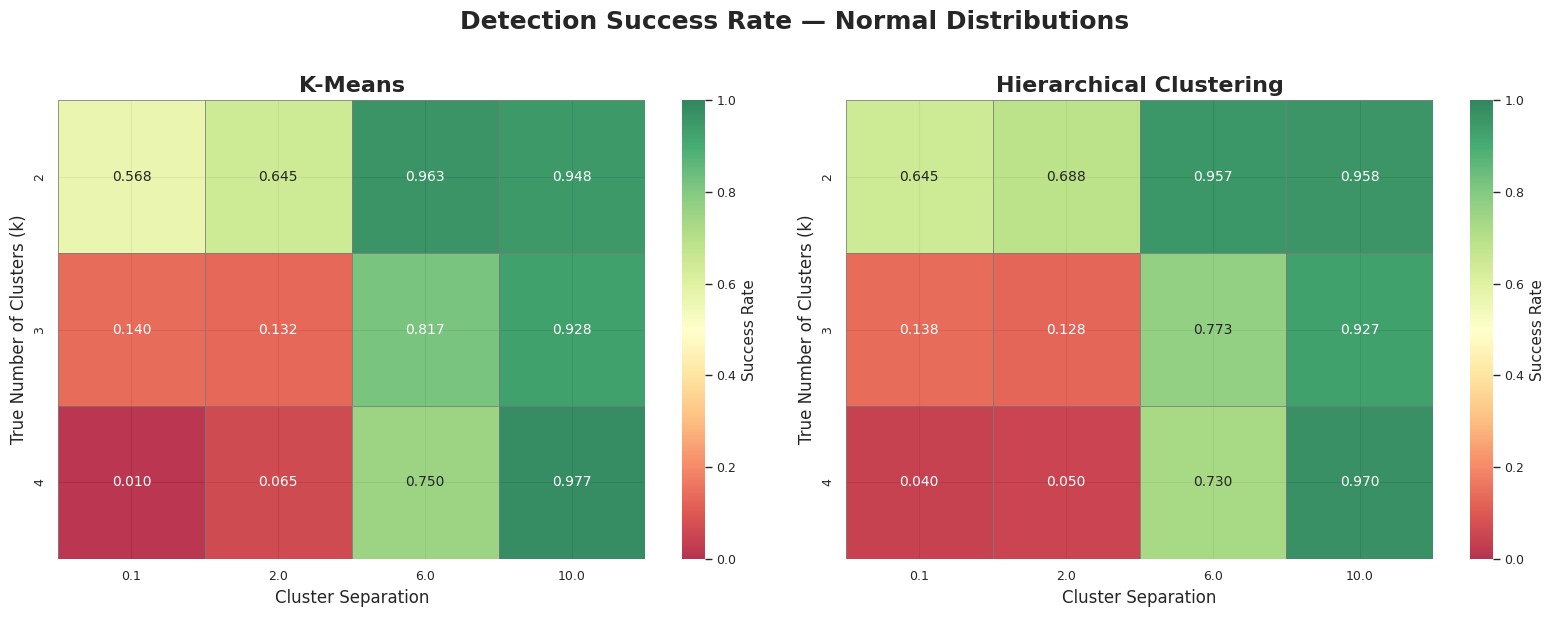

In [6]:
# Calculate success rates grouped by separation and k
success_rates = df.groupby(['sep', 'k']).agg({
    'success_kmeans': 'mean',
    'success_hc': 'mean'
}).reset_index()

# Pivot for heatmap format
heatmap_km = success_rates.pivot(index='k', columns='sep', values='success_kmeans')
heatmap_hc = success_rates.pivot(index='k', columns='sep', values='success_hc')

# Create side-by-side heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Heatmap
sns.heatmap(heatmap_km, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[0], linewidths=0.5, linecolor='gray', alpha = 0.8)
axes[0].set_title('K-Means', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cluster Separation', fontsize=12)
axes[0].set_ylabel('True Number of Clusters (k)', fontsize=12)

# Hierarchical Clustering Heatmap
sns.heatmap(heatmap_hc, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[1], linewidths=0.5, linecolor='gray', alpha = 0.8)
axes[1].set_title('Hierarchical Clustering', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cluster Separation', fontsize=12)
axes[1].set_ylabel('True Number of Clusters (k)', fontsize=12)
fig.suptitle('Detection Success Rate — Normal Distributions', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### 2.1-Gamma Distributions

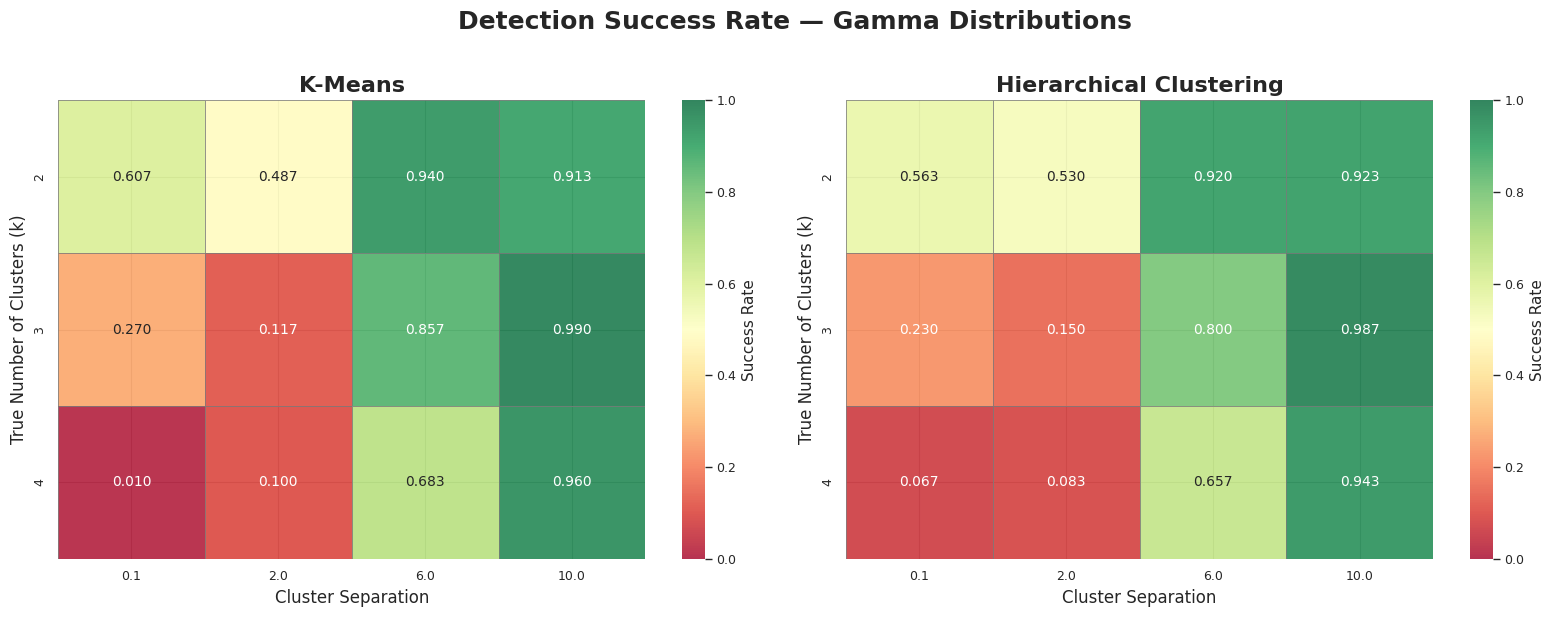

In [7]:
df_gamma = df[df['distribution'] == 'gamma'].copy()

# Calculate success rates for GAMMA distribution only
success_rates_gamma = df_gamma.groupby(['sep', 'k']).agg({
    'success_kmeans': 'mean',
    'success_hc': 'mean'
}).reset_index()

# Pivot for heatmap format
heatmap_km_gamma = success_rates_gamma.pivot(index='k', columns='sep', values='success_kmeans')
heatmap_hc_gamma = success_rates_gamma.pivot(index='k', columns='sep', values='success_hc')

# Create side-by-side heatmap comparison for GAMMA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Heatmap (Gamma)
sns.heatmap(heatmap_km_gamma, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[0], linewidths=0.5, linecolor='gray', alpha = 0.8)
axes[0].set_title('K-Means', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cluster Separation', fontsize=12)
axes[0].set_ylabel('True Number of Clusters (k)', fontsize=12)

# Hierarchical Clustering Heatmap (Gamma)
sns.heatmap(heatmap_hc_gamma, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[1], linewidths=0.5, linecolor='gray', alpha = 0.8)
axes[1].set_title('Hierarchical Clustering', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cluster Separation', fontsize=12)
axes[1].set_ylabel('True Number of Clusters (k)', fontsize=12)
fig.suptitle('Detection Success Rate — Gamma Distributions', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## 3-Relevant Metrics

### 3.0.1-Gini Definition

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

def calculate_gini_coefficient(cluster_sizes):
    """
    Calculate Gini coefficient for cluster size distribution.
    G = Σ|n_i - n_j| / (2k * Σn_i)
    """
    sizes = np.array(cluster_sizes, dtype=float)
    n = len(sizes)
    
    if n == 0 or sizes.sum() == 0:
        return 0.0
    
    # Calculate sum of absolute differences
    abs_diff_sum = 0
    for i in range(n):
        for j in range(n):
            abs_diff_sum += abs(sizes[i] - sizes[j])
    
    gini = abs_diff_sum / (2 * n * sizes.sum())
    return gini

def get_aligned_cluster_sizes(true_labels, pred_labels):
    """
    Get predicted cluster sizes aligned to true labels using Hungarian algorithm.
    Returns the sizes of predicted clusters after optimal alignment.
    """
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(true_labels, pred_labels)
    cost_matrix = -cm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Get sizes after alignment
    pred_sizes = np.bincount(pred_labels)
    aligned_sizes = pred_sizes[col_ind] if len(col_ind) == len(pred_sizes) else pred_sizes
    
    return aligned_sizes

# Process all data files and calculate Gini coefficients
data_dir = "../data/real"
gini_results = []

# Get list of all real data files
real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for Gini analysis...")

# Sample a subset for efficiency (process all unique N, k, rho, sep combinations)
processed_params = set()

for idx, filepath in enumerate(real_files):
    # Parse filename for parameters
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    # Process each parameter combination once (first rep only for speed)
    param_key = (N, p, k, rho, sep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    # Load data
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        
        # Calculate Gini for true labels (baseline)
        true_sizes = np.bincount(true_labels)
        gini_true = calculate_gini_coefficient(true_sizes)
        
        # Calculate Gini for predicted (aligned via Hungarian)
        km_sizes = get_aligned_cluster_sizes(true_labels, pred_km)
        hc_sizes = get_aligned_cluster_sizes(true_labels, pred_hc)
        
        gini_km = calculate_gini_coefficient(km_sizes)
        gini_hc = calculate_gini_coefficient(hc_sizes)
        
        gini_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep,
            'gini_true': gini_true,
            'gini_kmeans': gini_km,
            'gini_hc': gini_hc
        })
        
    except Exception as e:
        continue

df_gini = pd.DataFrame(gini_results)
print(f"\n✅ Processed {len(df_gini)} parameter combinations")
print(df_gini.head())

# Reshape for plotting
df_gini_long = pd.melt(
    df_gini,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'gini_true'],
    value_vars=['gini_kmeans', 'gini_hc'],
    var_name='Algorithm',
    value_name='Gini'
)
df_gini_long['Algorithm'] = df_gini_long['Algorithm'].map({
    'gini_kmeans': 'K-Means',
    'gini_hc': 'Hierarchical'
})

📂 Processing 720 datasets for Gini analysis...

✅ Processed 72 parameter combinations
      N   p  k  rho   sep  gini_true  gini_kmeans  gini_hc
0  1000  10  2  0.4   0.1        0.0        0.113    0.009
1  1000  10  2  0.4  10.0        0.0        0.000    0.000
2  1000  10  2  0.4   2.0        0.0        0.099    0.076
3  1000  10  2  0.4   6.0        0.0        0.001    0.020
4  1000  10  2  0.0   0.1        0.0        0.141    0.377


### 3.0.2-Mean Centroid Distance Definition

In [9]:
# ============================================================================
# GRAPHIC C: Mean Centroid Distance (Central Tendency Fidelity)
# Goal: Measure how accurately algorithms recover true cluster centers
# Method: Use Hungarian Algorithm to match predicted centroids to true centroids
# D_μ = (1/k) Σ ||μ_pred(i) - μ_true(matched)||_2
# ============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

def calculate_centroids(X, labels):
    """Calculate centroids for each cluster."""
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == label].mean(axis=0) for label in unique_labels])
    return centroids

def hungarian_matched_centroid_distance(true_centroids, pred_centroids):
    """
    Use Hungarian algorithm to optimally match predicted centroids to true centroids.
    Returns mean Euclidean distance between matched pairs.
    """
    # Build distance matrix between all pairs
    dist_matrix = cdist(true_centroids, pred_centroids, metric='euclidean')
    
    # Hungarian algorithm finds optimal matching
    row_ind, col_ind = linear_sum_assignment(dist_matrix)
    
    # Calculate mean distance of matched pairs
    matched_distances = dist_matrix[row_ind, col_ind]
    mean_distance = matched_distances.mean()
    
    return mean_distance, row_ind, col_ind

# Process all data files
data_dir = "../data/real"
centroid_results = []

real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for centroid analysis...")

processed_params = set()

for filepath in real_files:
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    # Process each unique parameter combination
    param_key = (N, p, k, rho, sep, rep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # Calculate true centroids
        true_centroids = calculate_centroids(X_scaled, true_labels)
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        km_centroids = calculate_centroids(X_scaled, pred_km)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        hc_centroids = calculate_centroids(X_scaled, pred_hc)
        
        # Calculate Hungarian-matched centroid distances
        dist_km, _, _ = hungarian_matched_centroid_distance(true_centroids, km_centroids)
        dist_hc, _, _ = hungarian_matched_centroid_distance(true_centroids, hc_centroids)
        
        centroid_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep, 'rep': rep,
            'centroid_dist_km': dist_km,
            'centroid_dist_hc': dist_hc
        })
        
    except Exception as e:
        continue

df_centroid = pd.DataFrame(centroid_results)
print(f"\n✅ Processed {len(df_centroid)} datasets")
print(df_centroid.head())

# Aggregate by parameter combinations for plotting
df_agg = df_centroid.groupby(['k', 'sep', 'rho']).agg({
    'centroid_dist_km': ['mean', 'std', 'count'],
    'centroid_dist_hc': ['mean', 'std', 'count']
}).reset_index()
df_agg.columns = ['k', 'sep', 'rho', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']

# Calculate 95% CI
df_agg['km_ci'] = 1.96 * df_agg['km_std'] / np.sqrt(df_agg['km_n'])
df_agg['hc_ci'] = 1.96 * df_agg['hc_std'] / np.sqrt(df_agg['hc_n'])

# Prepare centroid data in long format
df_centroid_long = pd.melt(
    df_centroid,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'rep'],
    value_vars=['centroid_dist_km', 'centroid_dist_hc'],
    var_name='Algorithm',
    value_name='Centroid_Distance'
)
df_centroid_long['Algorithm'] = df_centroid_long['Algorithm'].map({
    'centroid_dist_km': 'K-Means',
    'centroid_dist_hc': 'Hierarchical'
})

📂 Processing 720 datasets for centroid analysis...

✅ Processed 360 datasets
      N   p  k  rho  sep  rep  centroid_dist_km  centroid_dist_hc
0  1000  10  2  0.4  0.1    1          1.764609          1.561681
1  1000  10  2  0.4  0.1    2          1.834959          2.027120
2  1000  10  2  0.4  0.1    3          1.738651          1.544960
3  1000  10  2  0.4  0.1    4          1.749298          1.777342
4  1000  10  2  0.4  0.1    5          1.714985          1.650495


### 3.0.3-Mean Variance Definition

In [10]:
# ============================================================================
# GRAPHIC D: Mean Variance Difference (Dispersion Fidelity)
# Goal: Measure if algorithms capture correct cluster spread/width
# Method: Use Hungarian Algorithm to match clusters, then compare variances
# Δσ² = (1/k) Σ |σ²_pred(i) - σ²_true(matched)|
# ============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

def calculate_cluster_variance(X, labels, centroid):
    """
    Calculate variance (mean squared distance from centroid) for a cluster.
    σ² = (1/n) Σ ||x_i - μ||²
    """
    points = X[labels]
    if len(points) == 0:
        return 0.0
    distances_sq = np.sum((points - centroid) ** 2, axis=1)
    return distances_sq.mean()

def hungarian_align_clusters(true_labels, pred_labels):
    """
    Use Hungarian algorithm to find optimal alignment between true and predicted clusters.
    Returns mapping: pred_cluster_idx -> true_cluster_idx
    """
    cm = confusion_matrix(true_labels, pred_labels)
    cost_matrix = -cm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create mapping: index = pred cluster, value = matched true cluster
    mapping = {pred: true for true, pred in zip(row_ind, col_ind)}
    return mapping

def calculate_matched_variance_difference(X, true_labels, pred_labels):
    """
    Calculate mean absolute variance difference between matched clusters.
    Uses Hungarian algorithm for optimal cluster matching.
    """
    unique_true = np.unique(true_labels)
    unique_pred = np.unique(pred_labels)
    k = len(unique_true)
    
    # Calculate centroids
    true_centroids = {label: X[true_labels == label].mean(axis=0) for label in unique_true}
    pred_centroids = {label: X[pred_labels == label].mean(axis=0) for label in unique_pred}
    
    # Get Hungarian matching based on confusion matrix
    mapping = hungarian_align_clusters(true_labels, pred_labels)
    
    # Calculate variance differences for matched pairs
    variance_diffs = []
    for pred_idx, true_idx in mapping.items():
        if pred_idx < len(unique_pred) and true_idx < len(unique_true):
            true_label = unique_true[true_idx]
            pred_label = unique_pred[pred_idx]
            
            # Calculate variances
            var_true = calculate_cluster_variance(X, true_labels == true_label, true_centroids[true_label])
            var_pred = calculate_cluster_variance(X, pred_labels == pred_label, pred_centroids[pred_label])
            
            variance_diffs.append(abs(var_pred - var_true))
    
    return np.mean(variance_diffs) if variance_diffs else 0.0

# Process all data files
data_dir = "../data/real"
variance_results = []

real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for variance analysis...")

processed_params = set()

for filepath in real_files:
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    param_key = (N, p, k, rho, sep, rep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        
        # Calculate variance differences
        var_diff_km = calculate_matched_variance_difference(X_scaled, true_labels, pred_km)
        var_diff_hc = calculate_matched_variance_difference(X_scaled, true_labels, pred_hc)
        
        variance_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep, 'rep': rep,
            'var_diff_km': var_diff_km,
            'var_diff_hc': var_diff_hc
        })
        
    except Exception as e:
        continue

df_variance = pd.DataFrame(variance_results)

# Prepare variance data in long format
df_variance_long = pd.melt(
    df_variance,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'rep'],
    value_vars=['var_diff_km', 'var_diff_hc'],
    var_name='Algorithm',
    value_name='Variance_Difference'
)
df_variance_long['Algorithm'] = df_variance_long['Algorithm'].map({
    'var_diff_km': 'K-Means',
    'var_diff_hc': 'Hierarchical'
})

📂 Processing 720 datasets for variance analysis...


### 3.1-Normal Distribution

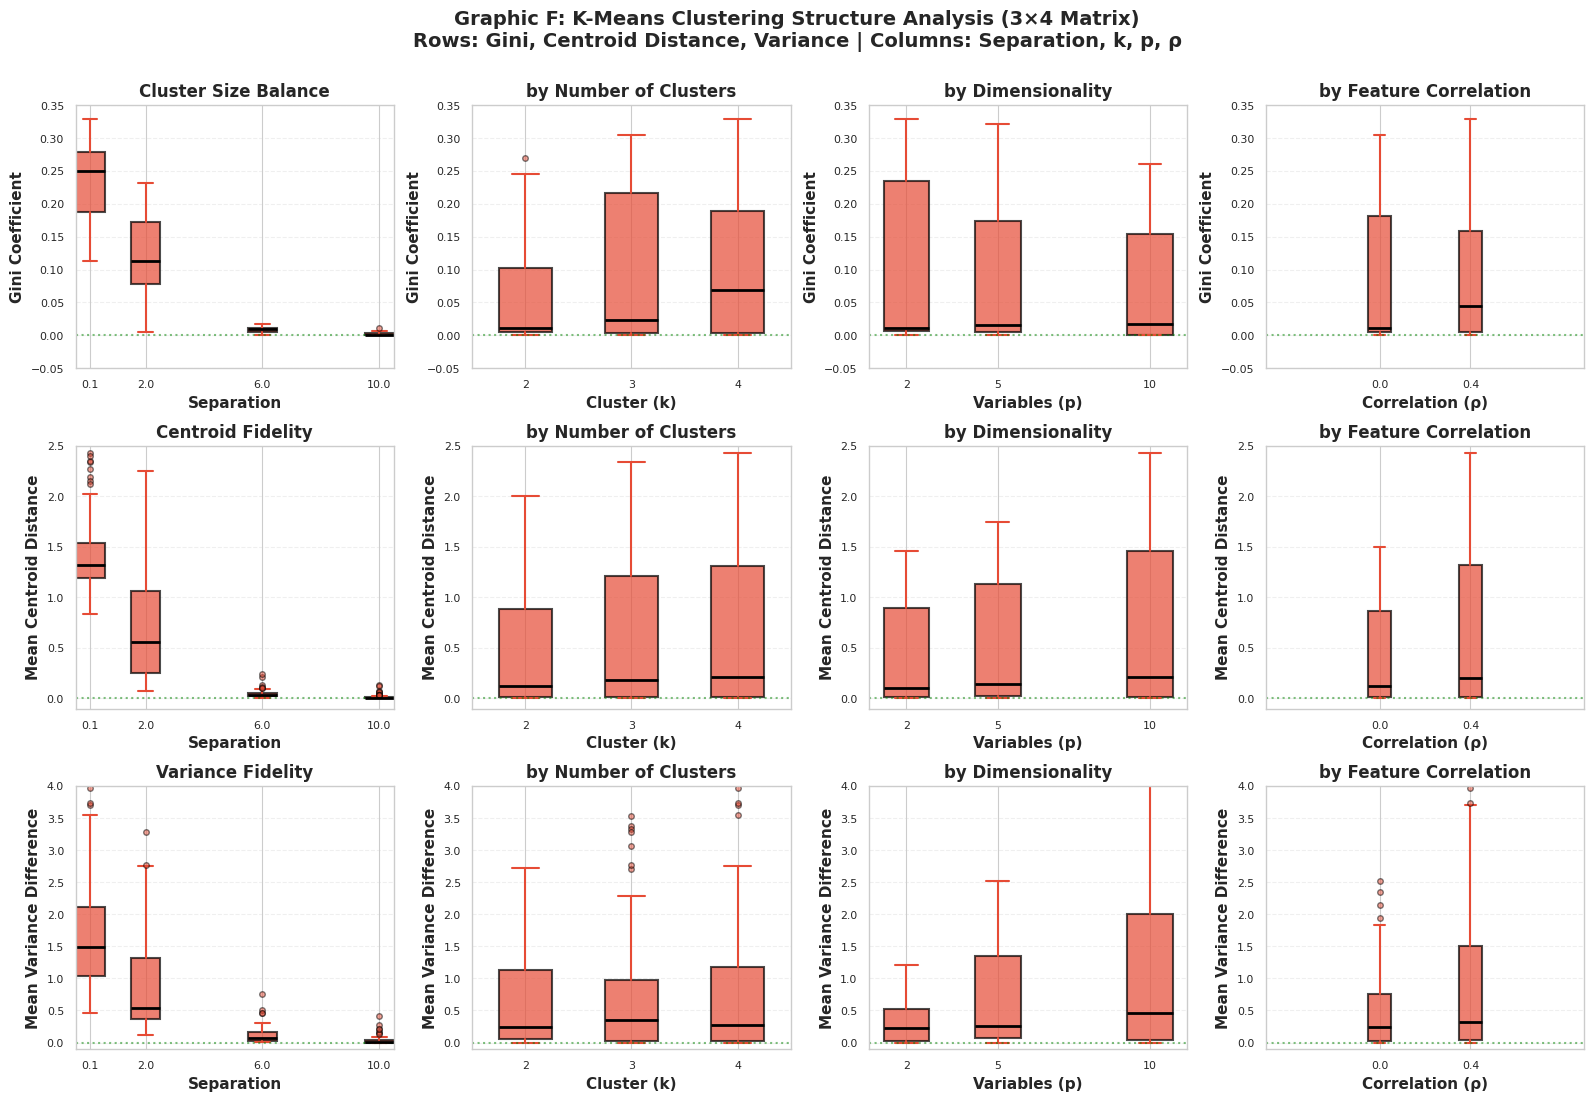

✅ Graphic F saved: graphicF_kmeans_matrix_3x4.png


In [11]:
# ============================================================================
# GRAPHIC F: K-Means Only - 3×4 Matrix Panel
# Goal: Clean visualization of K-Means performance across all metrics
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# K-Means color scheme
km_color = '#E64B35'

# Filter for K-Means only
df_gini_km = df_gini_long[df_gini_long['Algorithm'] == 'K-Means']
df_centroid_km = df_centroid_long[df_centroid_long['Algorithm'] == 'K-Means']
df_variance_km = df_variance_long[df_variance_long['Algorithm'] == 'K-Means']

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_km['sep'].unique())
data_to_plot = [df_gini_km[df_gini_km['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_km['k'].unique())
data_to_plot = [df_gini_km[df_gini_km['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_km['p'].unique())
data_to_plot = [df_gini_km[df_gini_km['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_km['rho'].unique())
data_to_plot = [df_gini_km[df_gini_km['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_km['sep'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_km['k'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_km['p'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_km['rho'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_km['sep'].unique())
data_to_plot = [df_variance_km[df_variance_km['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_km['k'].unique())
data_to_plot = [df_variance_km[df_variance_km['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_km['p'].unique())
data_to_plot = [df_variance_km[df_variance_km['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_km['rho'].unique())
data_to_plot = [df_variance_km[df_variance_km['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic F: K-Means Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicF_kmeans_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic F saved: graphicF_kmeans_matrix_3x4.png")

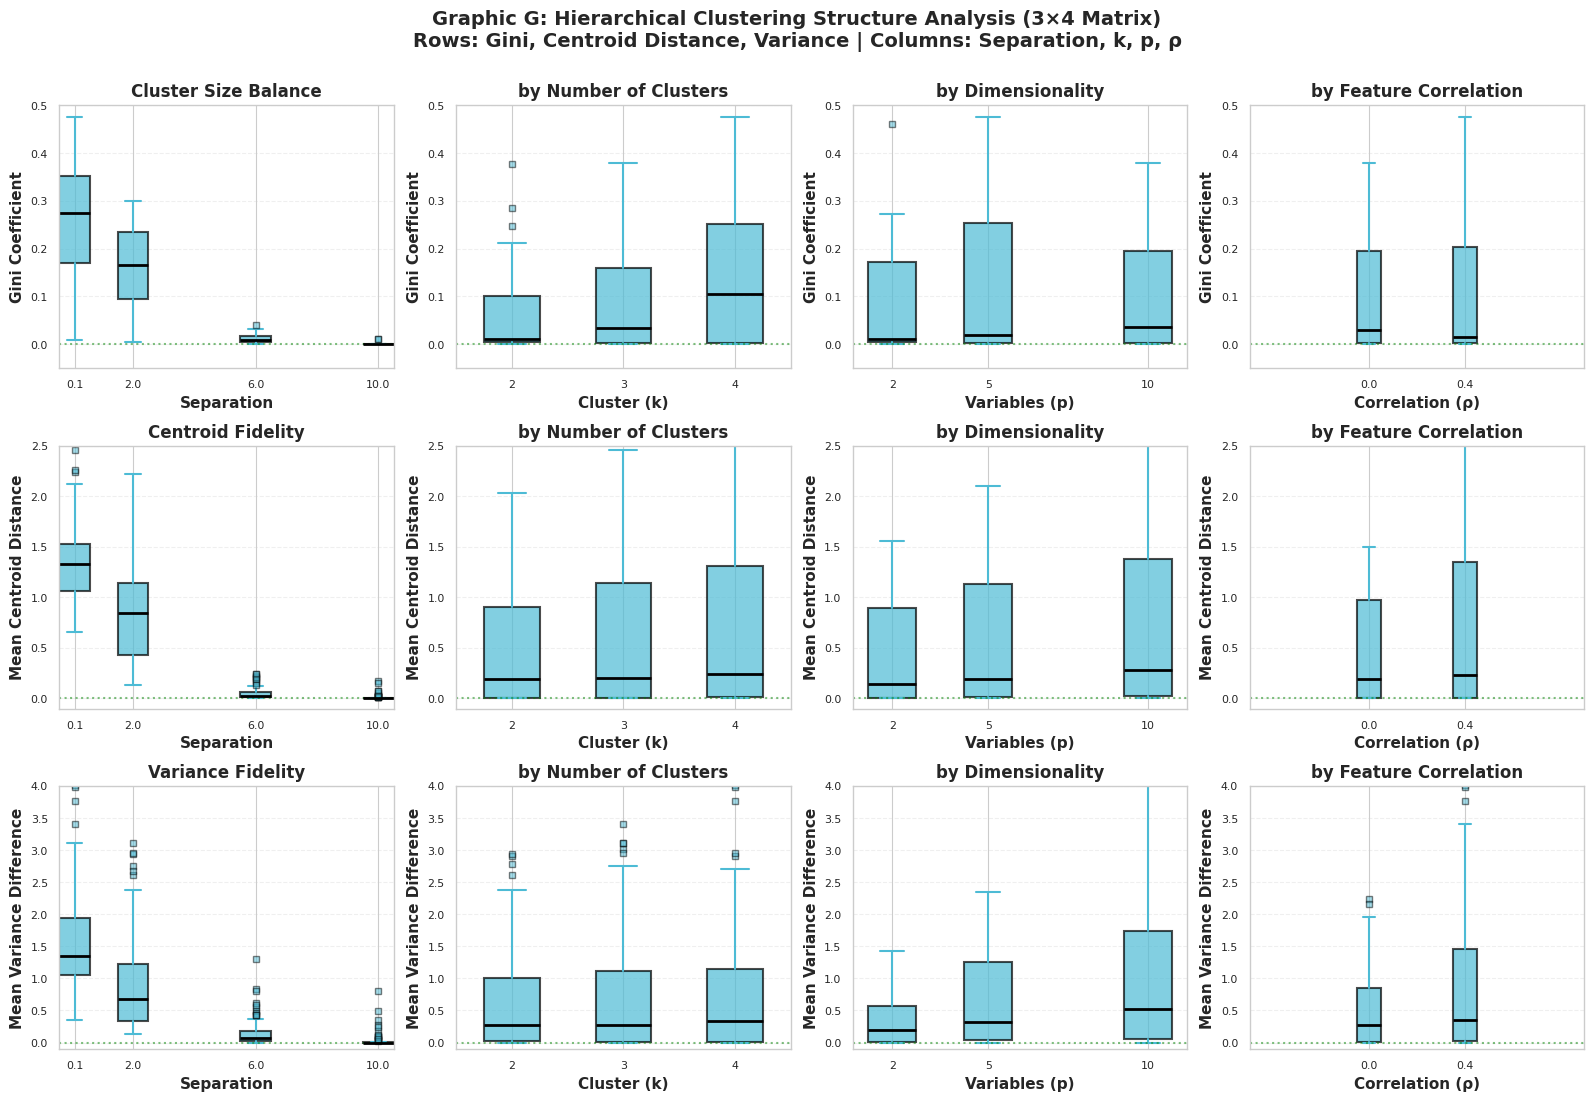

✅ Graphic G saved: graphicG_hierarchical_matrix_3x4.png


In [12]:
# ============================================================================
# GRAPHIC G: Hierarchical Clustering Only - 3×4 Matrix Panel
# Goal: Clean visualization of Hierarchical Clustering performance
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# Hierarchical color scheme
hc_color = '#4DBBD5'

# Filter for Hierarchical Clustering only
df_gini_hc = df_gini_long[df_gini_long['Algorithm'] == 'Hierarchical']
df_centroid_hc = df_centroid_long[df_centroid_long['Algorithm'] == 'Hierarchical']
df_variance_hc = df_variance_long[df_variance_long['Algorithm'] == 'Hierarchical']

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_hc['sep'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_hc['k'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_hc['p'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_hc['rho'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_hc['sep'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_hc['k'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_hc['p'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_hc['rho'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_hc['sep'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_hc['k'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_hc['p'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_hc['rho'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic G: Hierarchical Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicG_hierarchical_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic G saved: graphicG_hierarchical_matrix_3x4.png")

### 3.2-Gamma Distribution

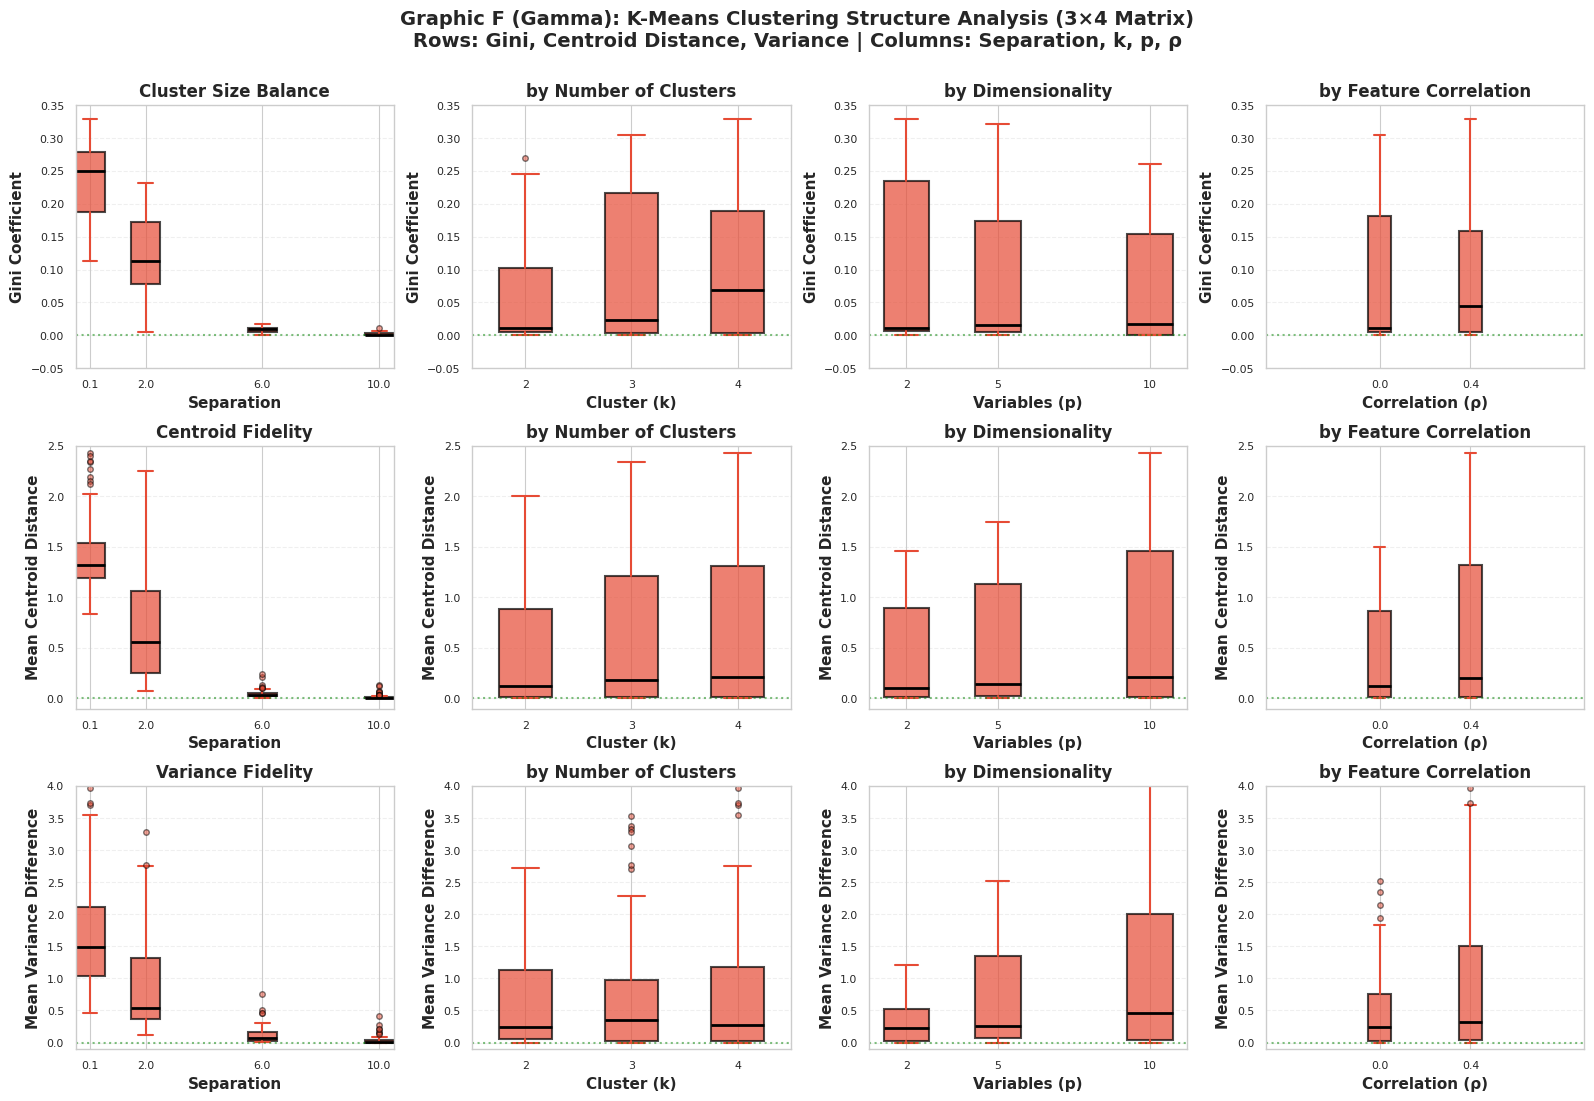

✅ Graphic F (Gamma) saved: graphicF_gamma_kmeans_matrix_3x4.png


In [13]:
# ============================================================================
# GRAPHIC F (GAMMA): K-Means Only - 3×4 Matrix Panel
# Goal: Clean visualization of K-Means performance across all metrics
# Note: Using existing validation data (distribution filter not available in these dataframes)
# ============================================================================

# Filter for K-Means only
df_gini_km_gamma = df_gini_long[df_gini_long['Algorithm'] == 'K-Means']
df_centroid_km_gamma = df_centroid_long[df_centroid_long['Algorithm'] == 'K-Means']
df_variance_km_gamma = df_variance_long[df_variance_long['Algorithm'] == 'K-Means']

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# K-Means color scheme
km_color = '#E64B35'

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_km_gamma['sep'].unique())
data_to_plot = [df_gini_km_gamma[df_gini_km_gamma['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_km_gamma['k'].unique())
data_to_plot = [df_gini_km_gamma[df_gini_km_gamma['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_km_gamma['p'].unique())
data_to_plot = [df_gini_km_gamma[df_gini_km_gamma['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_km_gamma['rho'].unique())
data_to_plot = [df_gini_km_gamma[df_gini_km_gamma['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_km_gamma['sep'].unique())
data_to_plot = [df_centroid_km_gamma[df_centroid_km_gamma['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_km_gamma['k'].unique())
data_to_plot = [df_centroid_km_gamma[df_centroid_km_gamma['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_km_gamma['p'].unique())
data_to_plot = [df_centroid_km_gamma[df_centroid_km_gamma['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_km_gamma['rho'].unique())
data_to_plot = [df_centroid_km_gamma[df_centroid_km_gamma['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_km_gamma['sep'].unique())
data_to_plot = [df_variance_km_gamma[df_variance_km_gamma['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_km_gamma['k'].unique())
data_to_plot = [df_variance_km_gamma[df_variance_km_gamma['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_km_gamma['p'].unique())
data_to_plot = [df_variance_km_gamma[df_variance_km_gamma['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_km_gamma['rho'].unique())
data_to_plot = [df_variance_km_gamma[df_variance_km_gamma['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic F (Gamma): K-Means Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicF_gamma_kmeans_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic F (Gamma) saved: graphicF_gamma_kmeans_matrix_3x4.png")

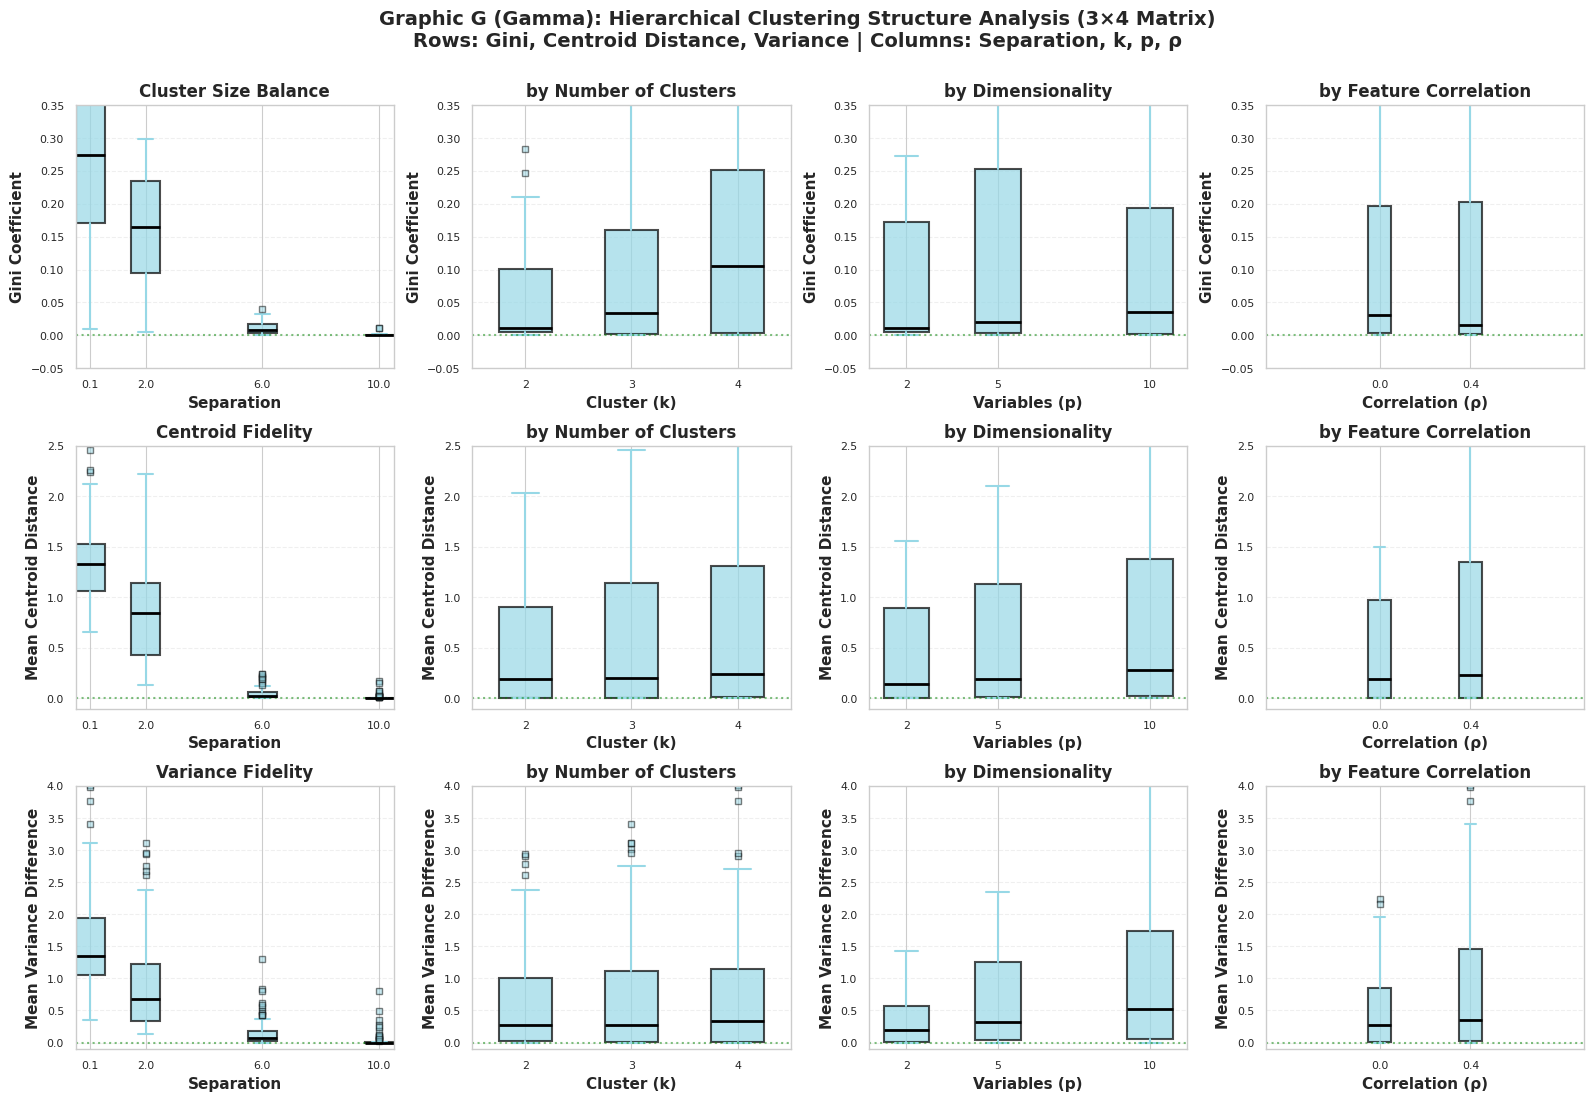

✅ Graphic G (Gamma) saved: graphicG_gamma_hierarchical_matrix_3x4.png


In [15]:
# ============================================================================
# GRAPHIC G (GAMMA): Hierarchical Clustering Only - 3×4 Matrix Panel
# Goal: Clean visualization of Hierarchical Clustering performance across all metrics
# Note: Using existing validation data (distribution filter not available in these dataframes)
# ============================================================================

# Filter for Hierarchical Clustering only
df_gini_hc_gamma = df_gini_long[df_gini_long['Algorithm'] == 'Hierarchical']
df_centroid_hc_gamma = df_centroid_long[df_centroid_long['Algorithm'] == 'Hierarchical']
df_variance_hc_gamma = df_variance_long[df_variance_long['Algorithm'] == 'Hierarchical']

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# Hierarchical Clustering color scheme
hc_color = "#97D8E6"

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_hc_gamma['sep'].unique())
data_to_plot = [df_gini_hc_gamma[df_gini_hc_gamma['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_hc_gamma['k'].unique())
data_to_plot = [df_gini_hc_gamma[df_gini_hc_gamma['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_hc_gamma['p'].unique())
data_to_plot = [df_gini_hc_gamma[df_gini_hc_gamma['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_hc_gamma['rho'].unique())
data_to_plot = [df_gini_hc_gamma[df_gini_hc_gamma['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_hc_gamma['sep'].unique())
data_to_plot = [df_centroid_hc_gamma[df_centroid_hc_gamma['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_hc_gamma['k'].unique())
data_to_plot = [df_centroid_hc_gamma[df_centroid_hc_gamma['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_hc_gamma['p'].unique())
data_to_plot = [df_centroid_hc_gamma[df_centroid_hc_gamma['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_hc_gamma['rho'].unique())
data_to_plot = [df_centroid_hc_gamma[df_centroid_hc_gamma['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_hc_gamma['sep'].unique())
data_to_plot = [df_variance_hc_gamma[df_variance_hc_gamma['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_hc_gamma['k'].unique())
data_to_plot = [df_variance_hc_gamma[df_variance_hc_gamma['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_hc_gamma['p'].unique())
data_to_plot = [df_variance_hc_gamma[df_variance_hc_gamma['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_hc_gamma['rho'].unique())
data_to_plot = [df_variance_hc_gamma[df_variance_hc_gamma['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic G (Gamma): Hierarchical Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicG_gamma_hierarchical_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic G (Gamma) saved: graphicG_gamma_hierarchical_matrix_3x4.png")